# **OCR engines Benchmark**

The objective of this notebook is made a benchmark between different OCR engines for the task of character read in the regions of interest (ID-Card elements).

Thanks to our ID-Card elements detector, we known the card zones to *read*, Whereby in this point is not necessary the use of a VLM *(Vision Language Model)* to detect and extract the characters from the images. Also by privacy and security reasons is not recommended send sensible data as *document number* or *MRZ-Machine Readable Zone* to public APIs on the cloud.

Inside of the OCR engies to test in this work, we are going to include a VLM open source *GOT-OCR 2.0 (General OCR Theory)*, with academic purposes for the its intregations on the project.

Therefore the open source OCR engines to test in this notebook are the following: 

* EasyOCR (Jaided AI)
* Tesseract OCR (Google)
* PaddleOCR (PP-OCRv4)
* GOT-OCR 2.0

We are going to take the `ground_truth` automatically generated and manually checked in the previous notebook to apply these techniques and then calculate the metrics by element.

The metricas to calculates are the following:

* Character Error Rate (CER)
* Exact Match (100% Accuracy)

## **Expected Input**

* Extracted and separated elements in folders in `data/prc/ocr_images_examples/<element_name>`.
* JSON files with `ground_truth` generated en `./ground_truth/<element_name>.json`.

## **Expected Output**
* Metrics.
* Selection of OCR engine to use in the application.
* Conclusions

## **Libraries and Settings**

In [38]:
from pathlib import Path
from tqdm import tqdm
from pytesseract import Output 
from paddleocr import PaddleOCR
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import math
import easyocr
import pytesseract 
import json
import Levenshtein
import pandas as pd

if not os.environ.get("BASE_PROJECT_DIR"):
    os.environ["BASE_PROJECT_DIR"] = input("Enter the base project directory path: ")

BASE_INPUT_DIR = Path(os.environ["BASE_PROJECT_DIR"]) / "data/prc/ocr_images_examples"

## **Auxiliar functions**

Define functions to:
* Pre-process image before OCR.
* Images visualizations.
* Complete extracted data through OCR
* Load JSON file. 

In [2]:
def pre_processing_image(img: np.ndarray, apply_thresh: bool = False) -> np.ndarray:
    """Pre-process the image for OCR."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Increase constrast and brightness
    contrast = 1.5
    bright = 0
    enhanced = cv2.addWeighted(gray, contrast, gray, 0, bright)

    # Make sure the values are in the range [0, 255]
    enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)
    if apply_thresh:
        binary = cv2.adaptiveThreshold(
            enhanced,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            11,
        )
        return binary
    return enhanced

def show_images(images:list[Path], title: str, apply_thresh: bool = False) -> None:
    """Show a list of images using matplotlib."""
    n_images = len(images)
    n_cols = math.ceil(math.sqrt(n_images))
    n_rows = math.ceil(n_images / n_cols)

    _, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 1))
    axs = np.array(axs).reshape(n_rows, n_cols)

    for i, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        img = pre_processing_image(img, apply_thresh)
        axs[i // n_cols, i % n_cols].imshow(img, cmap="gray")
        axs[i // n_cols, i % n_cols].set_title(f"Image {i + 1}")
        axs[i // n_cols, i % n_cols].axis("off")

    for j in range(n_images, n_rows * n_cols):
        axs[j // n_cols, j % n_cols].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [3]:
def complete_json_file(gt_json: list[dict],
                       value: str,
                       filename: str,
                       ocr_label: str) -> list[dict]:
    for item in gt_json:
        if filename in item:
            item[filename][ocr_label] = value
            break
    return gt_json

def get_gt_by_path(gt_path: str) -> list[dict]:
    with open(gt_path, "r") as f:
        gt_json = json.load(f)
    return gt_json

## **OCR Engine: `EasyOCR`**

Start trying the `EasyOCR` library

```
pip install easyocr
```

### **Document Number**

Load our document numbers and `ground_truth`. After visualize the images

In [4]:
DOC_NUMBER_IMAGES = list(Path(BASE_INPUT_DIR/ "doc_number").glob("*"))
doc_number_gt = get_gt_by_path(gt_path="./ground_truth/doc_number.json")

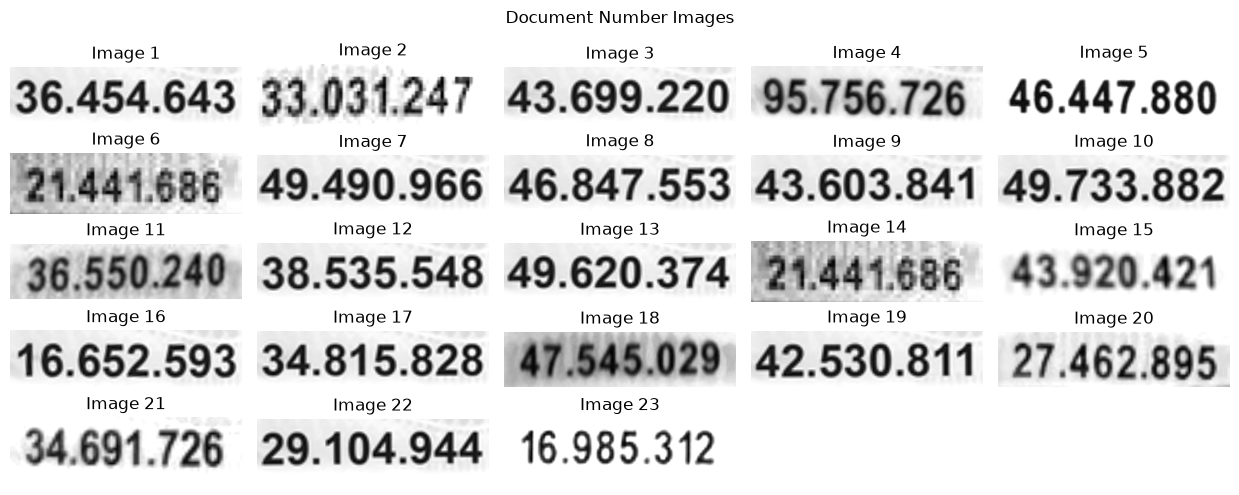

In [5]:
show_images(DOC_NUMBER_IMAGES, title="Document Number Images")

In [6]:
def read_text_by_easyocr(img: np.ndarray,
                         reader: easyocr.Reader,
                         apply_thresh: bool = False,
                         allowed_list: str = None) -> str:
    """Read text from an image using EasyOCR."""
    pre_processed_img = pre_processing_image(img, apply_thresh=apply_thresh)
    result = reader.readtext(pre_processed_img, paragraph=False, allowlist=allowed_list)
    result_text = " ".join([text for _, text, _ in result])
    return result_text

* Execute the reading of characters.

In [7]:
reader = easyocr.Reader(["es"], gpu=True)

for img_path in tqdm(DOC_NUMBER_IMAGES, desc="Reading text from images using EasyOCR"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_easyocr(img=img, reader=reader, allowed_list="0123456789.")
    complete_json_file(gt_json=doc_number_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="easyocr_pred")

Reading text from images using EasyOCR: 100%|██████████| 23/23 [00:00<00:00, 42.37it/s]


### **MRZ**

Load our MRZ and `ground_truth`. After visualize the images.

In [8]:
MRZ_IMAGES = list(Path(BASE_INPUT_DIR/ "mrz").glob("*"))
mrz_gt = get_gt_by_path(gt_path="./ground_truth/mrz.json")

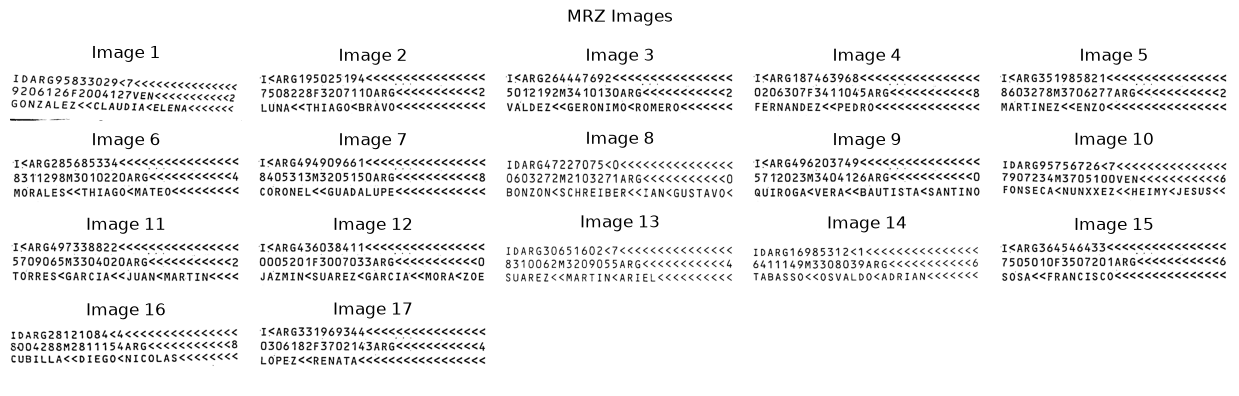

In [9]:
show_images(images=MRZ_IMAGES, title="MRZ Images", apply_thresh=True)

In [10]:
for img_path in tqdm(MRZ_IMAGES, desc="Reading text from images using EasyOCR"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_easyocr(img=img, reader=reader)
    complete_json_file(gt_json=mrz_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="easyocr_pred")

Reading text from images using EasyOCR: 100%|██████████| 17/17 [00:01<00:00, 11.51it/s]


### **Tramite number**

Load our tramite numberes and  `ground_truth`. After visualize the images.

In [11]:
TRAMITE_NUMBER_IMAGES = list(Path(BASE_INPUT_DIR/ "tramite_number").glob("*"))
tramite_number_gt = get_gt_by_path(gt_path="./ground_truth/tramite_number.json")

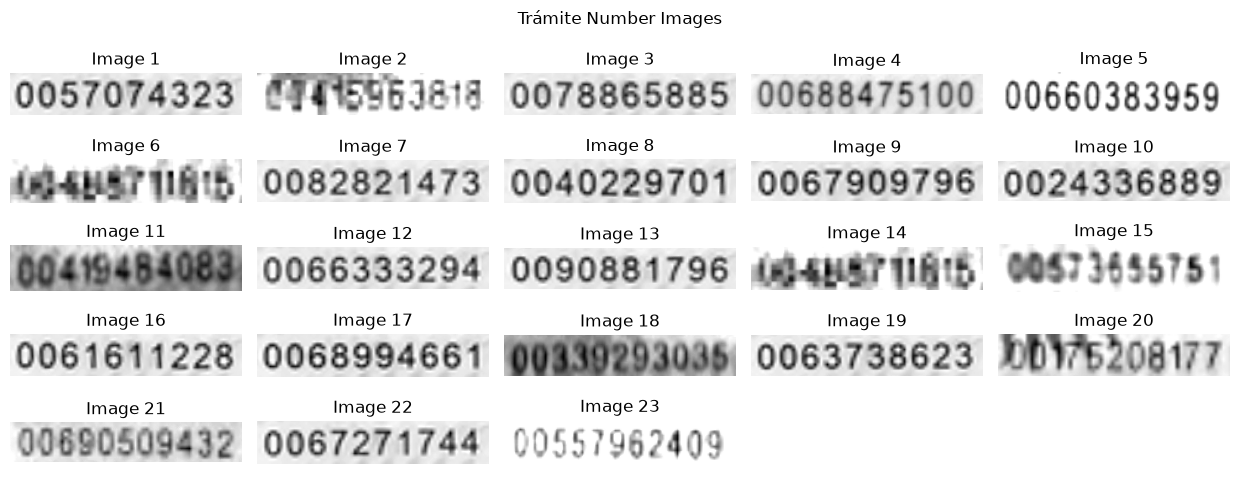

In [12]:
show_images(images=TRAMITE_NUMBER_IMAGES, title="Trámite Number Images")

In [13]:
for img_path in tqdm(TRAMITE_NUMBER_IMAGES, desc="Reading text from images using EasyOCR"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_easyocr(img=img, reader=reader)
    complete_json_file(gt_json=tramite_number_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="easyocr_pred")

Reading text from images using EasyOCR: 100%|██████████| 23/23 [00:00<00:00, 76.73it/s]


### **Address**

Load our addresses and `ground_truth`. After visualize the images.

In [14]:
ADDRESS_IMAGES = list(Path(BASE_INPUT_DIR/ "address").glob("*"))
address_gt = get_gt_by_path(gt_path="./ground_truth/address.json")

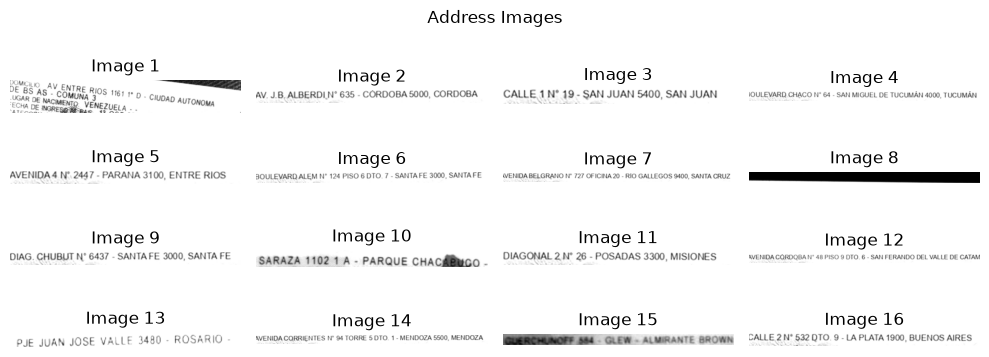

In [15]:
show_images(images=ADDRESS_IMAGES, title="Address Images")

In [16]:
for img_path in tqdm(ADDRESS_IMAGES, desc="Reading text from images using EasyOCR"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_easyocr(img=img, reader=reader)
    complete_json_file(gt_json=address_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="easyocr_pred")

Reading text from images using EasyOCR: 100%|██████████| 16/16 [00:00<00:00, 18.48it/s]


## **OCR Engine: `TesseractOCR`**

Tesseract OCR is the industry-standard free, open-source option.

To do this, repeat the process has made for `easyocr` for our elements and save the result in each element dict with the next key `tesseract_pred`.

In [17]:
def read_text_by_tesseract(img:np.ndarray,
                           apply_thresh: bool = False,
                           lang: str = "eng",
                           ocr_config: str = '') -> str:
    """Read text from an image using Tesseract OCR."""
    pre_processed_img = pre_processing_image(img, apply_thresh=apply_thresh)
    data = pytesseract.image_to_data(pre_processed_img, output_type=Output.DICT, lang=lang, config=ocr_config)
    text = "".join(data["text"])
    return text

In [18]:
# Document Number OCR using Tesseract
for img_path in tqdm(DOC_NUMBER_IMAGES, desc="Reading text from images using Tesseract"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_tesseract(img=img, apply_thresh=False, lang="spa", ocr_config="--psm 6")
    complete_json_file(gt_json=doc_number_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="tesseract_pred")

# Tramite Number OCR using Tesseract
for img_path in tqdm(TRAMITE_NUMBER_IMAGES, desc="Reading text from images using Tesseract"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_tesseract(img=img, apply_thresh=False, lang="spa", ocr_config="--psm 8")
    complete_json_file(gt_json=tramite_number_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="tesseract_pred")

# MRZ OCR using Tesseract
for img_path in tqdm(MRZ_IMAGES, desc="Reading text from images using Tesseract"):
    img = cv2.imread(str(img_path))
    ocr_text = read_text_by_tesseract(img=img, apply_thresh=False, lang="spa", ocr_config="--psm 6")
    complete_json_file(gt_json=mrz_gt,
                       value=ocr_text,
                       filename=img_path.name,
                       ocr_label="tesseract_pred")

# Address OCR using Tesseract
for img_path in tqdm(ADDRESS_IMAGES, desc="Reading text from images using Tesseract"):
    img = cv2.imread(str(img_path))
    img = pre_processing_image(img, apply_thresh=True)
    data = pytesseract.image_to_data(img, output_type=Output.DICT, lang="spa", config='--psm 6')
    text = " ".join(data["text"])
    complete_json_file(gt_json=address_gt,
                       value=text,
                       filename=img_path.name,
                       ocr_label="tesseract_pred")

Reading text from images using Tesseract: 100%|██████████| 16/16 [00:01<00:00,  9.38it/s]


## **OCR Engine: `PaddleOCR`**

Currently is one of the best OCR engines scene-text open source on the market.


To do this, repeat the process has made for the previous engines for our elements and save the result in each element dict with the next key `paddleocr_pred`.

In [19]:
def extract_text_by_paddleocr(img: np.ndarray,
                              ocr_engine: PaddleOCR) -> str:
    """Read text from an image using PaddleOCR."""
    result = ocr_engine.predict(img)[0]
    return result['rec_texts']

In [20]:
ocr = PaddleOCR(use_doc_orientation_classify=False,
                use_doc_unwarping=False,
                use_textline_orientation=False,
                lang="en")

/home/nahuel/Documentos/Python/DNI/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/nahuel/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/nahuel/.paddlex/official_models/PP-OCRv6_medium_rec`.


In [22]:
# Document Number OCR using PaddleOCR
for img_path in tqdm(DOC_NUMBER_IMAGES, desc="Reading text from images using PaddleOCR"):
    img = cv2.imread(str(img_path))
    text = extract_text_by_paddleocr(img=img, ocr_engine=ocr)
    text = "".join(text)
    # print(f"Image: {img_path.name} - Len: {len(text)} - OCR Text: {text}")
    complete_json_file(gt_json=doc_number_gt,
                       value=text,
                       filename=img_path.name,
                       ocr_label="paddleocr_pred")

# Tramite Number OCR using PaddleOCR
for img_path in tqdm(TRAMITE_NUMBER_IMAGES, desc="Reading text from images using PaddleOCR"):
    img = cv2.imread(str(img_path))
    text = extract_text_by_paddleocr(img=img, ocr_engine=ocr)
    text = "".join(text)
    # print(f"Image: {img_path.name} - Len: {len(text)} - OCR Text: {text}")
    complete_json_file(gt_json=tramite_number_gt,
                       value=text,
                       filename=img_path.name,
                       ocr_label="paddleocr_pred")

# MRZ OCR using PaddleOCR
for img_path in tqdm(MRZ_IMAGES, desc="Reading text from images using PaddleOCR"):
    img = cv2.imread(str(img_path))
    text = extract_text_by_paddleocr(img=img, ocr_engine=ocr)
    text = "\n".join(text)
    complete_json_file(gt_json=mrz_gt,
                       value=text,
                       filename=img_path.name,
                       ocr_label="paddleocr_pred")

# Address OCR using PaddleOCR
for img_path in tqdm(ADDRESS_IMAGES, desc="Reading text from images using PaddleOCR"):
    img = cv2.imread(str(img_path))
    text = extract_text_by_paddleocr(img=img, ocr_engine=ocr)
    text = " ".join(text)
    complete_json_file(gt_json=address_gt,
                       value=text,
                       filename=img_path.name,
                       ocr_label="paddleocr_pred")

Reading text from images using PaddleOCR: 100%|██████████| 16/16 [00:17<00:00,  1.12s/it]


* Save the JSON files

In [24]:
with open("./ground_truth/doc_number.json", "w") as f:
    json.dump(doc_number_gt, f, indent=4)

with open("./ground_truth/tramite_number.json", "w") as f:
    json.dump(tramite_number_gt, f, indent=4)

with open("./ground_truth/mrz.json", "w") as f:
    json.dump(mrz_gt, f, indent=4)

with open("./ground_truth/address.json", "w") as f:
    json.dump(address_gt, f, indent=4, ensure_ascii=False)

#### **Important**

You can found the examples with *GOT-OCR 2.0* in the follow notebook [05_optional_GOT_OCR2.0](https://github.com/nahueltabasso/Argentine_DNI_project/blob/main/research/01-ID-card-elements-data-extraction/05_optional_GOT_OCR2.0_example_v1.0.0.ipynb).




## **Calculate Metric by element**

In this section, calculate the metrics *CER* and *Exact Match* for each element

In [37]:
def compute_metrics(gt: str, pred: str) -> tuple:
    """Calculate CER and Exact Match for a pair of texts."""
    gt = gt.strip()
    pred = pred.strip()
    # Calculate Exact Match (1 if they are the same, 0 otherwise)
    exact_match = int(gt == pred)
    # Calculate Character Error Rate (CER)
    distance = Levenshtein.distance(gt, pred)
    if len(gt) > 0:
        cer = distance / len(gt)
    else:
        cer = 0.0 if len(pred) == 0 else 1.0
    
    return cer, exact_match

def evaluate_ocr_results(data: list[dict], element: str) -> pd.DataFrame:
    """Evaluate OCR results and return a DataFrame with metrics."""
    if not data or len(data) == 0:
        raise ValueError("The input data is empty or not in the expected format.")

    first_item = list(data[0].values())[0]
    ocr_engines = [key for key in first_item.keys() if key != "ground_truth"]
    print(f"OCR Engines found: {ocr_engines}")

    stats = {key: {"exact_matches":0, "sum_cer": 0.0, "total": 0} for key in ocr_engines}
    print(f"Initialized stats: {stats}")

    for item in data:
        for key, value in item.items():
            gt = value.get("ground_truth", "")

            for engine in ocr_engines:
                pred = value.get(engine, "")
                cer, exact_match = compute_metrics(gt, pred)
                
                stats[engine]["exact_matches"] += exact_match
                stats[engine]["sum_cer"] += cer
                stats[engine]["total"] += 1

    summary = []
    for engine in ocr_engines:
        total = stats[engine]["total"]
        exact_acc = ((stats[engine]["exact_matches"] / total) * 100 if total > 0 else 0)
        mean_cer = ((stats[engine]["sum_cer"] / total) * 100 if total > 0 else 0)
        engine_clean_name = engine.replace("_pred", "").upper()

        summary.append(
            {
                "Element": element,
                "Engine": engine_clean_name,
                "Exact Match (%)": round(exact_acc, 2),
                "Mean CER (%)": round(mean_cer, 2),
                "Total Samples": total,
            }
        )

    return pd.DataFrame(summary)

### **Metrics for Document Number**

In [39]:
with open("./ground_truth/doc_number.json", "r") as f:
    data = json.load(f)

In [45]:
doc_number_df = evaluate_ocr_results(data, "Document Number")
doc_number_df.to_json("./ocr_engines_metrics/doc_number_metrics.json", orient="records", indent=4)
doc_number_df

OCR Engines found: ['easyocr_pred', 'tesseract_pred', 'paddleocr_pred']
Initialized stats: {'easyocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'tesseract_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'paddleocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}}


,Element,Engine,Exact Match (%),Mean CER (%),Total Samples
0,Document Number,EASYOCR,69.57,15.42,23
1,Document Number,TESSERACT,73.91,18.18,23
2,Document Number,PADDLEOCR,91.30,8.70,23


### **Metrics for Tramite Number**

In [40]:
with open("./ground_truth/tramite_number.json", "r") as f:
    data = json.load(f)

In [44]:
tramite_number_df = evaluate_ocr_results(data, "Tramite Number")
tramite_number_df.to_json("./ocr_engines_metrics/tramite_number_metrics.json", orient="records", indent=4)
tramite_number_df

OCR Engines found: ['easyocr_pred', 'tesseract_pred', 'paddleocr_pred']
Initialized stats: {'easyocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'tesseract_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'paddleocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}}


,Element,Engine,Exact Match (%),Mean CER (%),Total Samples
0,Tramite Number,EASYOCR,69.57,15.42,23
1,Tramite Number,TESSERACT,73.91,18.18,23
2,Tramite Number,PADDLEOCR,91.30,8.70,23


### **Metrics for MRZ**

In [55]:
def normalize_text(text: str) -> str:
    text = text.replace(" ", "").replace("\n", "").replace("[", "").replace("]", "")
    text = text.replace("(", "").replace(")", "").replace("{", "").replace("}", "")
    return text

In [46]:
with open("./ground_truth/mrz.json", "r") as f:
    data = json.load(f)

In [57]:
# First normalize the text for all OCR engines in the MRZ data
for item in data:
    for key, value in item.items():
        for engine in value.keys():
            value[engine] = normalize_text(value[engine])


mrz_df = evaluate_ocr_results(data, "MRZ")
mrz_df.to_json("./ocr_engines_metrics/mrz_metrics.json", orient="records", indent=4)
mrz_df

OCR Engines found: ['easyocr_pred', 'tesseract_pred', 'paddleocr_pred']
Initialized stats: {'easyocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'tesseract_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'paddleocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}}


,Element,Engine,Exact Match (%),Mean CER (%),Total Samples
0,MRZ,EASYOCR,52.94,1.37,17
1,MRZ,TESSERACT,58.82,2.61,17
2,MRZ,PADDLEOCR,94.12,0.07,17


### **Metrics for Addresses**

In [58]:
with open("./ground_truth/address.json", "r") as f:
    data = json.load(f)

In [60]:
address_df = evaluate_ocr_results(data, "Address")
address_df.to_json("./ocr_engines_metrics/address_metrics.json", orient="records", indent=4)
address_df

OCR Engines found: ['easyocr_pred', 'tesseract_pred', 'paddleocr_pred']
Initialized stats: {'easyocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'tesseract_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}, 'paddleocr_pred': {'exact_matches': 0, 'sum_cer': 0.0, 'total': 0}}


,Element,Engine,Exact Match (%),Mean CER (%),Total Samples
0,Address,EASYOCR,0.00,37.59,17
1,Address,TESSERACT,0.00,38.22,17
2,Address,PADDLEOCR,11.76,30.45,17
